In [42]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import json
import matplotlib.patches as patches
from scipy.spatial import distance

In [65]:
model = YOLO("yolov8n.pt")
image_data = Image.open('GsyM72flP5s_1150.png')
results = model.predict(image_data,classes=[0],conf=0.2,show=True)


0: 384x640 7 persons, 153.5ms
Speed: 6.7ms preprocess, 153.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


In [66]:
[list(image_data.size)[0]//2,list(image_data.size)[1]//2]

[640, 360]

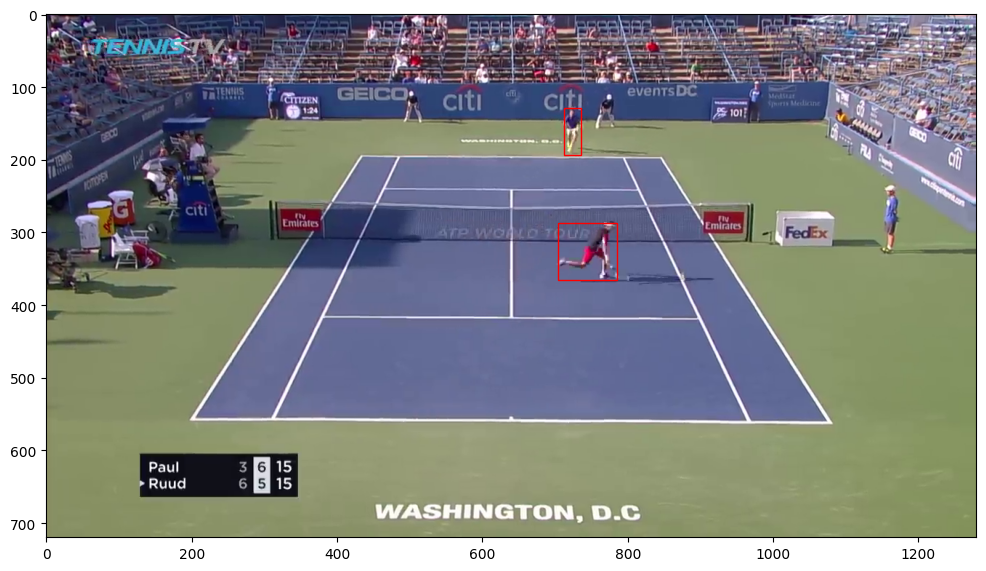

In [88]:
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
distance_centre = pd.DataFrame(columns=['distance'])
image_centre = [list(image_data.size)[0]//2,list(image_data.size)[1]//2]
for result in results:
  for number,box in enumerate(result.boxes.xyxy.tolist()):
    distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
for result in results:
    for number,box in enumerate(result.boxes.xywh.tolist()):
      if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
    boxes.append(result.boxes.xyxy.tolist())
plt.show()

In [84]:
distance_centre.sort_values(by='distance',ascending=True)[:2].index

Index([0, 2], dtype='int64')